<a href="https://colab.research.google.com/github/kirtia1289/chromium/blob/main/ystockpred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.0305
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 3.6725e-04
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 3.6247e-04
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 3.1518e-04
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 3.4650e-04
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 3.5683e-04
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 3.0600e-04
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 2.8946e-04
Epoch 9/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 3.4954e-04
Epoch 10/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 2.8534e-04
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


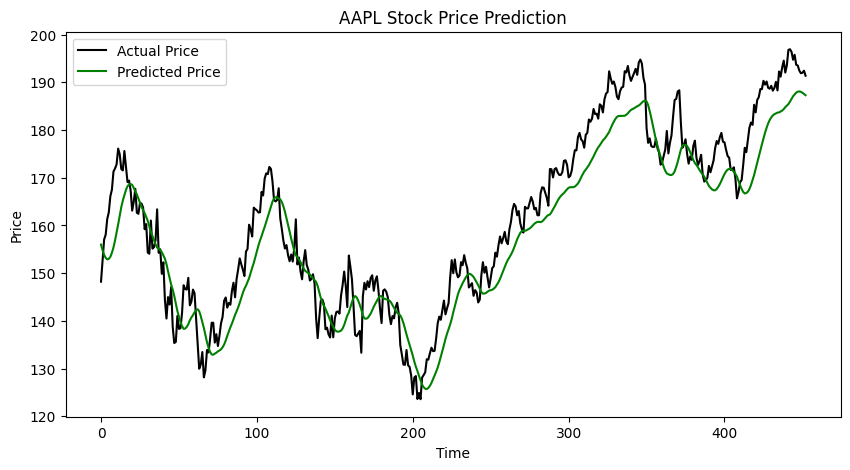

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import yfinance as yf


# Load dataset
df = yf.download('AAPL', start='2015-01-01', end='2023-12-31')
df = df[['Close']]  # Using 'Close' price only
df.dropna(inplace=True)

# Normalize data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Create training dataset
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - 60:]

# Create sequences
def create_dataset(data, seq_length=60):
    x, y = [], []
    for i in range(seq_length, len(data)):
        x.append(data[i - seq_length:i])
        y.append(data[i])
    return np.array(x), np.array(y)

x_train, y_train = create_dataset(train_data)
x_test, y_test = create_dataset(test_data)

# Reshape for LSTM [samples, time steps, features]
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

# Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(60, 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=10, batch_size=32)

# Predict and inverse transform
predicted = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(actual_prices, color='black', label='Actual Price')
plt.plot(predicted_prices, color='green', label='Predicted Price')
plt.title('AAPL Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()
